In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt    
import seaborn as sns

# Set professional aesthetics for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'axes.titleweight': 'bold'})

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, accuracy_score, precision_score, 
                             recall_score, f1_score, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc)

# NEW: Importing XGBoost instead of RandomForest
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# imblearn imports for SMOTE and Pipeline
# Important: We must use Imblearn's Pipeline to prevent data leakage during CV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ================================
# 1. Load Data & Basic Exploration


In [3]:
# ================================
print("Loading data...")
data = pd.read_csv("creditcard.csv")

print("\nFirst 5 rows of the dataset:")
display(data.head(5))

print("\nStatistical summary of the dataset:")
display(data.describe())

fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]

outlierFraction = len(fraud) / float(len(valid))
print(f"\nOutlier Fraction: {outlierFraction:.5f}")
print(f"Fraud Cases: {len(fraud)}")
print(f"Valid Transactions: {len(valid)}")

print("\nAmount details of the fraudulent transactions:")
print(fraud.Amount.describe())

print("\nAmount details of valid transactions:")
print(valid.Amount.describe())



Loading data...

First 5 rows of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Statistical summary of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Outlier Fraction: 0.00173
Fraud Cases: 492
Valid Transactions: 284315

Amount details of the fraudulent transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Amount details of valid transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [4]:
# ================================
# Premium Visualization 1: Targeted Correlation Plot



Generating Targeted Correlation Plot...


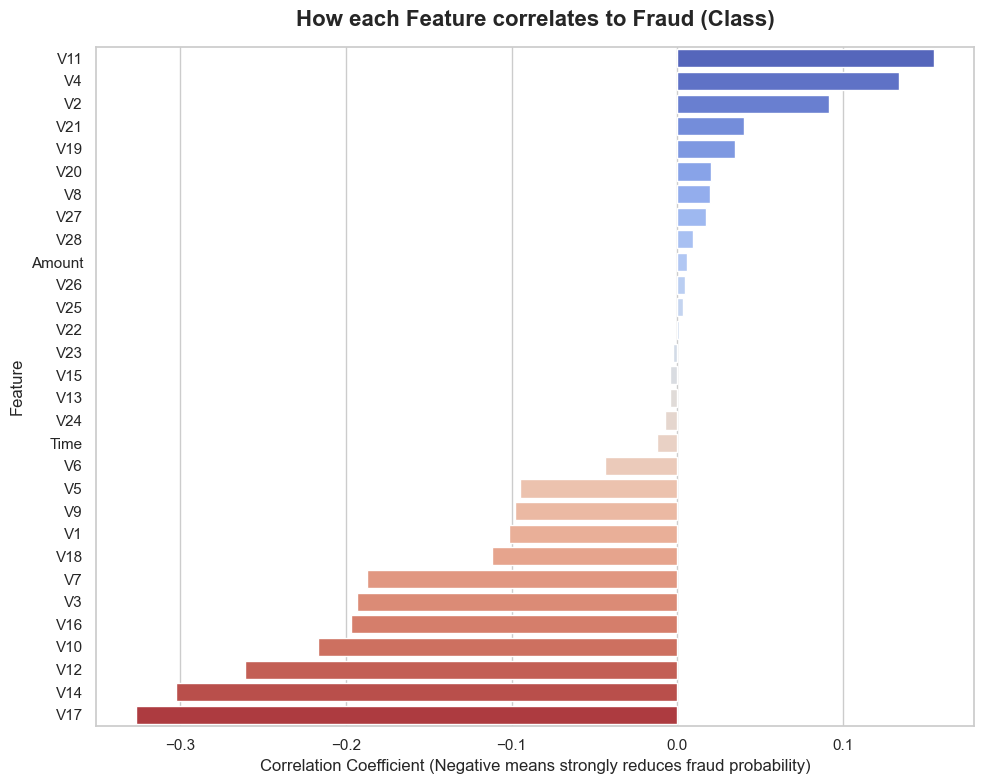

In [5]:
# ================================
# Instead of a messy 30x30 heatmap, we isolate exactly what correlates with 'Class'
print("\nGenerating Targeted Correlation Plot...")
corr = data.corrwith(data['Class']).reset_index()
corr.columns = ['Feature', 'Correlation']
corr = corr[corr['Feature'] != 'Class'] # Remove self-correlation
corr = corr.sort_values(by='Correlation', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    x='Correlation', 
    y='Feature', 
    data=corr, 
    palette=sns.color_palette("coolwarm", len(corr)),
    ax=ax
)
ax.set_title("How each Feature correlates to Fraud (Class)", fontsize=16, pad=15)
ax.set_xlabel("Correlation Coefficient (Negative means strongly reduces fraud probability)")
plt.tight_layout()
plt.show()



In [6]:
# ================================
# Premium Visualization 2: Distribution of Transaction Amounts (Fraud vs Normal)


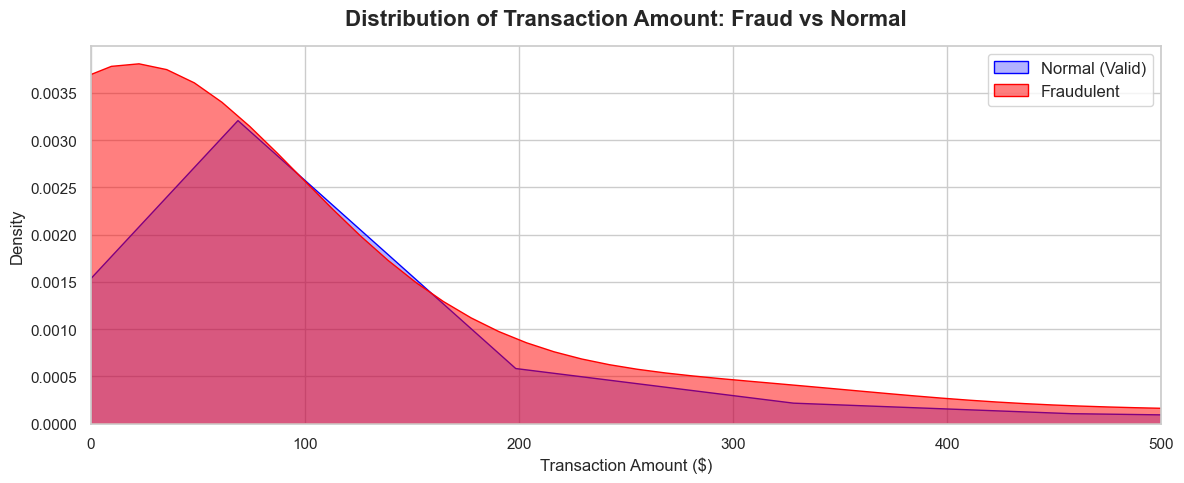

In [7]:
# ================================
# KDE plot visually proves Fraudsters spend money differently
fig, ax = plt.subplots(figsize=(12, 5))

# We limit the x-axis to $500 because vast majority of transactions are small
sns.kdeplot(valid['Amount'], fill=True, color='blue', label='Normal (Valid)', alpha=0.3, ax=ax)
sns.kdeplot(fraud['Amount'], fill=True, color='red', label='Fraudulent', alpha=0.5, ax=ax)

ax.set_title("Distribution of Transaction Amount: Fraud vs Normal", fontsize=16, pad=15)
ax.set_xlabel("Transaction Amount ($)")
ax.set_ylabel("Density")
ax.set_xlim(0, 500)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()



In [8]:
# ================================
# 2. Data Splitting


In [9]:
# ================================
# Dividing the X and the Y from the dataset
X = data.drop(['Class'], axis=1)
Y = data["Class"]

print("\nData Shape:")
print(f"X: {X.shape}, Y: {Y.shape}")

# TASK 1: Perform train_test_split BEFORE applying SMOTE to prevent data leakage
# Stratify ensures the class balance remains consistent in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X.values, Y.values, test_size=0.2, random_state=42, stratify=Y.values
)




Data Shape:
X: (284807, 30), Y: (284807,)


In [10]:
# ================================
# 3. Build Proper Pipeline with XGBoost


In [11]:
# ================================
# TASK 4: Build Proper Pipeline using imblearn.pipeline
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),                 # Feature scaling
    ('smote', SMOTE(random_state=42)),            # Apply SMOTE only on training data
    
    # NEW: Using XGBClassifier instead of RandomForest
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
    ))
])



In [12]:
# ================================
# 4. Model Training with GridSearchCV


In [13]:
# ================================
# TASK 3: Add GridSearchCV with XGBoost specific parameters
param_grid = {
    'classifier__n_estimators': [100, 200],  # Number of trees (boosting rounds)
    'classifier__max_depth': [3, 5],         # Depth of each tree (lower prevents overfitting)
    'classifier__learning_rate': [0.1, 0.01] # Step size shrinkage
}

# Wrap pipeline inside GridSearchCV
# Optimizing for recall is crucial in fraud detection
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall',       # Optimize for recall
    n_jobs=1,               # Let XGBoost handle the multiprocessing
    verbose=2               # Print progress
)

# TASK 5: Model Training
print("\nStarting XGBoost model training with GridSearchCV (this may take a few minutes)...")
grid_search.fit(X_train, y_train)




Starting XGBoost model training with GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time=   6.3s
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time=   1.5s
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time=   1.2s
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time=   1.2s
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time=   1.1s
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=200; total time=   1.7s
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=200; total time=   2.3s
[CV] END classifier__learning_rate=0.1, classifier__max_de

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_types=None,
                                                      f...
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=1,
             param_grid={'classifier__learning_rate': [0.1, 0.01],
                         'classifier__max_depth': [3, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='recall', verbose=2)

In [14]:
# ================================
# 5. Output Details & Best Model


In [15]:
# ================================
# TASK 7: Output Best Params and Score
print("\n--- GridSearchCV Results ---")
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Recall Score: {grid_search.best_score_:.4f}")

# Extract the most optimized model
best_model = grid_search.best_estimator_




--- GridSearchCV Results ---
Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best Cross-Validation Recall Score: 0.8932


In [16]:
# ================================
# 6. Evaluation on Test Data


In [17]:
# ================================
# TASK 6: Evaluation
print("\nEvaluating the best XGBoost model on test data...")
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Printing Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print("\n--- Model Metrics ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"MCC      : {mcc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Evaluating the best XGBoost model on test data...

--- Model Metrics ---
Accuracy : 0.9879
Precision: 0.1123
Recall   : 0.8776
F1-score : 0.1991
MCC      : 0.3114

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.11      0.88      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.93      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [18]:
# ================================
# Premium Visualization 3: Confusion Matrix


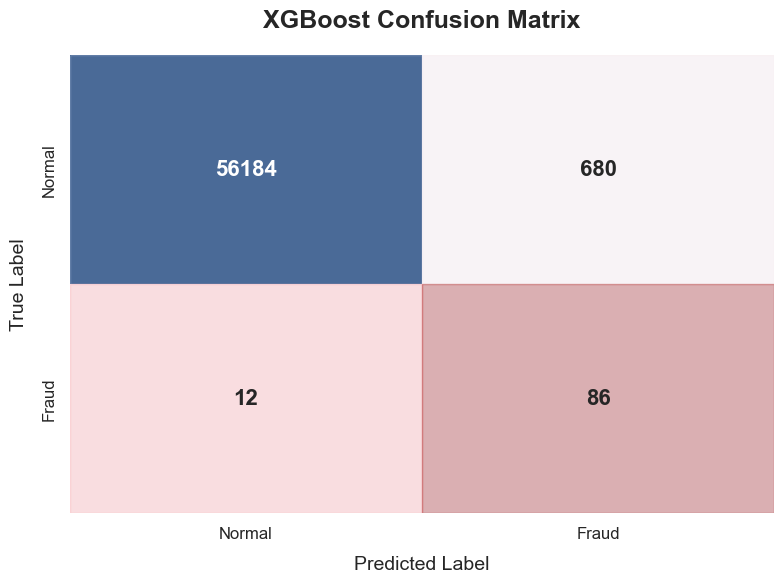

In [19]:
# ================================
LABELS = ['Normal', 'Fraud']
conf_matrix = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

# Use a highly professional dark-red/blue custom palette for the matrix
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",       # Base color map
    cbar=False,
    xticklabels=LABELS,
    yticklabels=LABELS,
    annot_kws={"size": 16, "weight": "bold"},
    ax=ax
)

# Hard-code specific premium colors conditionally (Red for Danger/Misses, Green for Safety)
from matplotlib.patches import Rectangle
cell_colors = [
    ["#E6F2FF", "#FFE6E6"],  # TN (Light Blue), FP (Light Red)
    ["#FF9999", "#990000"]   # FN (Red), TP (Dark Red)
]
for i in range(2):
    for j in range(2):
        ax.add_patch(Rectangle((j, i), 1, 1, fill=True, color=cell_colors[i][j], alpha=0.3))

ax.set_title("XGBoost Confusion Matrix", fontsize=18, pad=20, weight='bold')
ax.set_xlabel("Predicted Label", fontsize=14, labelpad=10)
ax.set_ylabel("True Label", fontsize=14, labelpad=10)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
plt.tight_layout()
plt.show()



In [20]:
# ================================
# Premium Visualization 4: ROC Curve


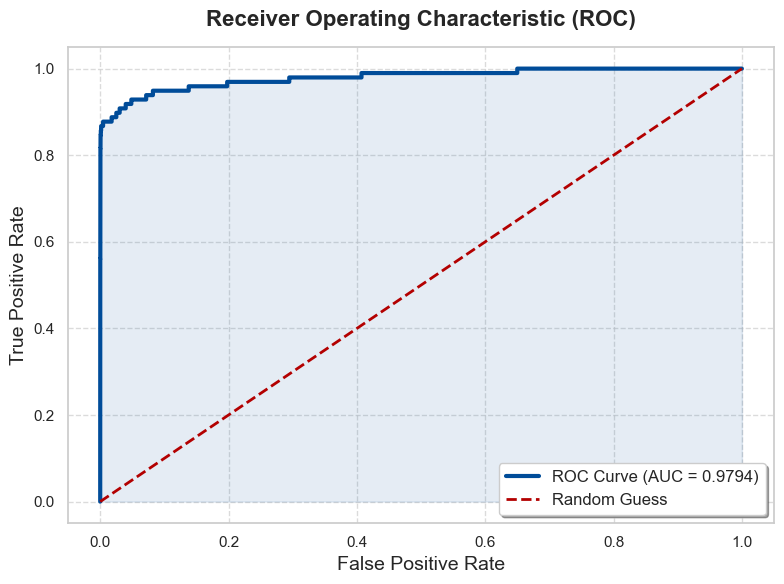

In [21]:
# ================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#004C99', linewidth=3, label=f"ROC Curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color='#B30000', linestyle='--', linewidth=2, label='Random Guess')
ax.fill_between(fpr, tpr, color='#004C99', alpha=0.1) # Add slight modern shading

ax.set_title("Receiver Operating Characteristic (ROC)", fontsize=16, pad=15, weight='bold')
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate", fontsize=14)
ax.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [22]:
# ================================
# Premium Visualization 5: Feature Importance Analysis


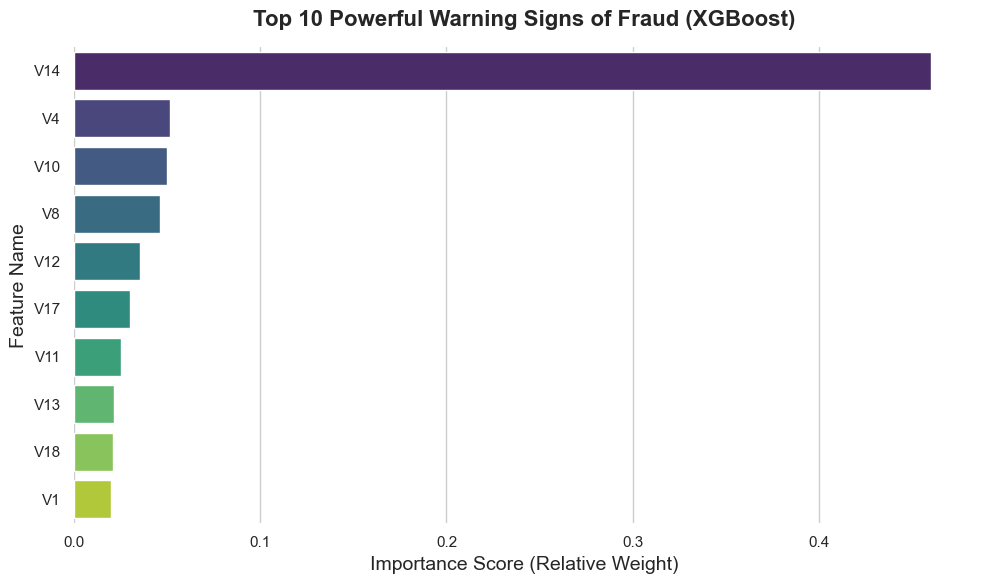

In [23]:
# ================================
# Fetch the importances from the XGBoost classifier inside our pipeline
importances = best_model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10) # Just Top 10

# Plot top 10 features with a sleek diverging palette
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df,
    palette="viridis",
    ax=ax
)

ax.set_title("Top 10 Powerful Warning Signs of Fraud (XGBoost)", fontsize=16, pad=15, weight='bold')
ax.set_xlabel("Importance Score (Relative Weight)", fontsize=14)
ax.set_ylabel("Feature Name", fontsize=14)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()



In [24]:
# ================================
# 8. Real-life Prediction Demo


In [25]:
# ================================
print("\n--- Real-life Prediction Demo ---")
sample_transaction = X_test[0].reshape(1, -1)
prediction = best_model.predict(sample_transaction)

if prediction[0] == 1:
    print("Prediction: 🔴 FRAUDULENT transaction detected!")
else:
    print("Prediction: 🟢 NORMAL transaction approved.")



--- Real-life Prediction Demo ---
Prediction: 🟢 NORMAL transaction approved.
